In [2]:
import os
import nsbi_common_utils
import pandas as pd
import numpy as np
import mplhep as hep
import pickle
import matplotlib.pyplot as plt
from nsbi_common_utils.training.utils import load_trained_model


/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:10: FutureWarning: ``set_style`` is deprecated: Naming convention is changing to match mpl. Use ``mplhep.style.use()``.
  hep.set_style("ATLAS")


In [3]:
BASE_PATH = "./data_nsbi_tutorial/"

In [4]:
nodes = [0, 5, 10]

signals = {
    f"signal_{n:g}": pd.read_parquet(f"{BASE_PATH}/signal_{n:g}.parquet") for n in nodes
}
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

In [5]:
TOTAL_YIELD = {}
TOTAL_YIELD["signal"] = signals["signal_10"].weight.sum()
TOTAL_YIELD["background"] = background.weight.sum()

In [6]:
asimov_dataset = pd.concat([background, signals["signal_10"]], ignore_index=True).astype('float32').copy()
weights_asimov = np.array(asimov_dataset.weight)
PATH_TO_WEIGHTS = "saved_weights/asimov_weight_array.npy"
os.makedirs(os.path.dirname(PATH_TO_WEIGHTS), exist_ok=True)
np.save(PATH_TO_WEIGHTS, weights_asimov)

In [7]:
training_features = ["x1", "x2", "x3", "x4", "x5"]


In [8]:
PATH_TO_RATIOS = {}
PATH_TO_RATIOS["signal"] = "saved_ratios_asimov/ratio_sig10vsRef.npy"
PATH_TO_RATIOS["background"] = "saved_ratios_asimov/ratio_BkgvsRef.npy"

In [9]:
for path in PATH_TO_RATIOS.values():
    os.makedirs(os.path.dirname(path), exist_ok=True)

In [10]:
path_to_saved_scaler = f"models_sig10vsRef/model_scaler0.bin"
path_to_saved_model  = f"models_sig10vsRef/model0.onnx"
path_to_calibrated_object = f"models_sig10vsRef/model_calibrated_hist0.obj"

scaler, model = load_trained_model(path_to_saved_model, path_to_saved_scaler)

file_calib = open(path_to_calibrated_object, 'rb') 
histogram_calibrator = pickle.load(file_calib)

prediction = nsbi_common_utils.training.utils.predict_with_model(asimov_dataset[training_features], 
                                                                scaler = scaler, 
                                                                model = model,
                                                                calibration_model = histogram_calibrator,
                                                                use_log_loss = False)

prediction_ratio = prediction / (1.0 - prediction)
np.save(PATH_TO_RATIOS["signal"], prediction_ratio)

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


In [11]:
path_to_saved_scaler = f"models_BkgvsRef/model_scaler0.bin"
path_to_saved_model  = f"models_BkgvsRef/model0.onnx"

scaler, model = load_trained_model(path_to_saved_model, path_to_saved_scaler)

prediction = nsbi_common_utils.training.utils.predict_with_model(asimov_dataset[training_features], 
                                                                scaler = scaler, 
                                                                model = model)

prediction_ratio = prediction / (1.0 - prediction)
np.save(PATH_TO_RATIOS["background"], prediction_ratio)

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


In [12]:
def make_workspace():
    """Toy workspace for this example."""
    return {
        "channels": [{
            "name": "SR",
            "type": "unbinned",
            "weights": PATH_TO_WEIGHTS,
            "samples": [
                {"name": "signal",
                 "data": [TOTAL_YIELD["signal"]],
                 "ratios": PATH_TO_RATIOS["signal"],
                 "modifiers": [{"name": "mu", "type": "normfactor"}]},
                {"name": "background",
                 "data": [TOTAL_YIELD["background"]],
                 "ratios": PATH_TO_RATIOS["background"],
                 "modifiers": [{"name": "mu_bkg", "type": "normfactor"}]},
            ],
        }],
        # "observations": [{"name": "SR", "data": DATA}],
        "measurements": [{
            "name": "meas",
            "config": {
                "poi": "mu",
                "parameters": [
                    {"bounds": [[0, 10]], "inits": [1], "name": "mu"},
                    {"bounds": [[0, 10]], "inits": [1], "name": "mu_bkg"},
                ],
            },
        }],
        "version": "1.0.0",
    }


In [13]:
ws_nsbi = make_workspace()
model_nsbi = nsbi_common_utils.models.sbi_parametric_model(workspace=ws_nsbi, 
                                                            measurement_to_fit="meas")

In [14]:
list_params, init_values = model_nsbi.get_model_parameters()
num_unconstrained = model_nsbi.num_unconstrained_param

In [15]:
inf_nsbi = nsbi_common_utils.inference.inference(
            model_nll=model_nsbi.model,
            initial_values=init_values,
            list_parameters=list_params,
            num_unconstrained_params=num_unconstrained,
            model_grad=model_nsbi.model_grad
        )

In [16]:
freeze_params = []

In [17]:
print("\n" + "="*40)
print(" NSBI FIT RESULTS ")
print("="*40 + "\n")
inf_nsbi.perform_fit(freeze_params=freeze_params)


 NSBI FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.566e+07                 │         Nfcn = 50, Ngrad = 1         │
│ EDM = 1.7e-08 (Goal: 0.0002)     │            time = 0.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬─────────

In [18]:
scan_points_nsbi, NLL_value_nsbi, scan_points_StatOnly_nsbi, NLL_value_StatOnly_nsbi = inf_nsbi.perform_profile_scan(parameter_name = 'mu', 
                             freeze_params = [], 
                             bound_range = (0.0, 2.0), 
                             fit_strategy = 0, 
                             doStatOnly = True,
                             size = 50)

(0.0, 2.0, 0.0, 10.0)

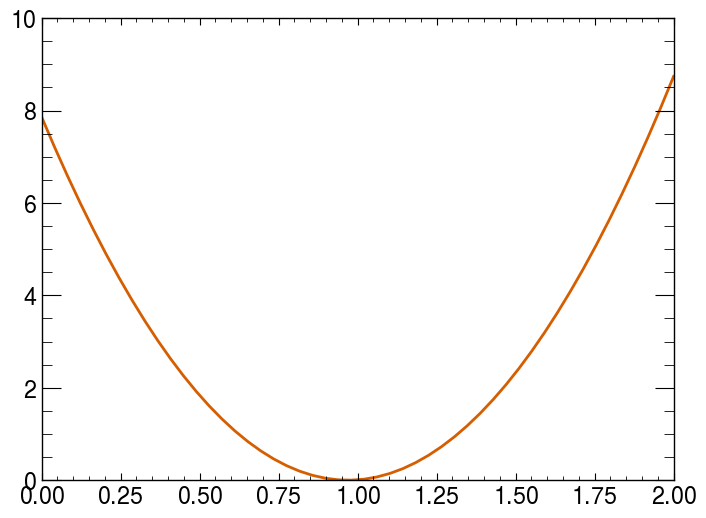

In [19]:
plt.plot(scan_points_nsbi, NLL_value_nsbi)
plt.axis(ymin=0)